# Task 3 Exploiting Correlation

## Objective
- Pick government securities from one country
- F

In [1]:
# Install required package if not already installed
!pip install pandas_datareader --quiet

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from sklearn.decomposition import PCA

# Set display and plotting preferences
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
# Define FRED tickers for 5 maturities
tickers = ["DGS1MO", "DGS3MO", "DGS2", "DGS5", "DGS10"]

# Fetch 6 months of daily data
yields = pdr.DataReader(tickers, 'fred', start='2025-04-01')

# Drop missing values (some days no trading)
yields = yields.dropna()

print("✅ Data Retrieved Successfully")
print(yields.head())


✅ Data Retrieved Successfully
            DGS1MO  DGS3MO  DGS2  DGS5  DGS10
DATE                                         
2025-04-01    4.38    4.32  3.87  3.91   4.17
2025-04-02    4.38    4.32  3.91  3.95   4.20
2025-04-03    4.36    4.31  3.71  3.75   4.06
2025-04-04    4.36    4.28  3.68  3.72   4.01
2025-04-07    4.36    4.29  3.73  3.82   4.15


In [3]:
print(yields)

            DGS1MO  DGS3MO  DGS2  DGS5  DGS10
DATE                                         
2025-04-01    4.38    4.32  3.87  3.91   4.17
2025-04-02    4.38    4.32  3.91  3.95   4.20
2025-04-03    4.36    4.31  3.71  3.75   4.06
2025-04-04    4.36    4.28  3.68  3.72   4.01
2025-04-07    4.36    4.29  3.73  3.82   4.15
...            ...     ...   ...   ...    ...
2025-09-26    4.22    4.02  3.63  3.76   4.20
2025-09-29    4.22    4.04  3.63  3.74   4.15
2025-09-30    4.20    4.02  3.60  3.74   4.16
2025-10-01    4.17    4.01  3.55  3.68   4.12
2025-10-02    4.23    4.02  3.55  3.67   4.10

[128 rows x 5 columns]


In [4]:
# Compute daily yield changes (Δy_t = y_t - y_(t-1))
yield_changes = yields.diff().dropna()

print("✅ Daily yield changes (in % points):")
print(yield_changes.head())


✅ Daily yield changes (in % points):
            DGS1MO  DGS3MO  DGS2  DGS5  DGS10
DATE                                         
2025-04-02    0.00    0.00  0.04  0.04   0.03
2025-04-03   -0.02   -0.01 -0.20 -0.20  -0.14
2025-04-04    0.00   -0.03 -0.03 -0.03  -0.05
2025-04-07    0.00    0.01  0.05  0.10   0.14
2025-04-08    0.00    0.02 -0.02  0.06   0.11


In [5]:
# Run PCA
pca = PCA()
pca.fit(yield_changes)

# Explained variance ratio (in %)
explained_var = pca.explained_variance_ratio_ * 100

# Print results
for i, var in enumerate(explained_var, 1):
    print(f"Component {i}: {var:.2f}% variance explained")


Component 1: 83.65% variance explained
Component 2: 7.06% variance explained
Component 3: 5.53% variance explained
Component 4: 2.88% variance explained
Component 5: 0.88% variance explained


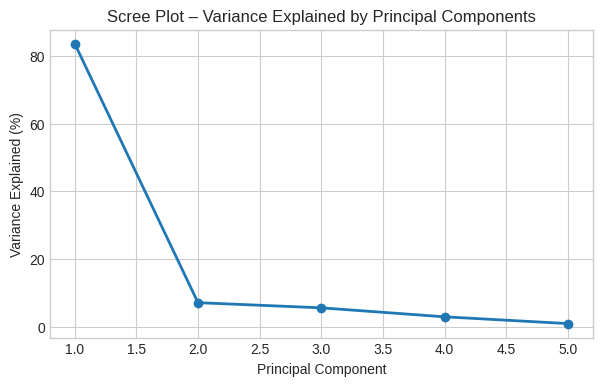

In [6]:
#Scree Plot

plt.figure(figsize=(7,4))
plt.plot(range(1, len(explained_var)+1), explained_var, 'o-', linewidth=2)
plt.title("Scree Plot – Variance Explained by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.show()


we’ll compare:

This real yield data scree plot
vs
The uncorrelated Gaussian data scree plot (from part 1, which we’ve to do next).